In [9]:
from src.data import pointcloud_processing, timeseries_processing, config, pc_statistics, utils
from src.data.config import TARGET_EXTENTS_VIF, TARGET_EXTENTS_VIF_SPLITS, ROOF_EXTENT, TARGET_DISTANCES
from src.data.utils import flatten_multiindex

import pandas as pd
import pickle

from matplotlib import pyplot as plt
import numpy as np
import plotly.graph_objects as go
import plotly.express as px

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR

## Load Met Data from Bagfile

In [10]:
BAG_NAMES = [
    "molisens_met_2023_08_07-15_36_45_converted",  # reference
    "molisens_met_2023_08_29-06_04_46_converted",
    "molisens_met_2023_08_29-08_21_47_converted",
]
PICKLE_DATA_DIR = config.PROCESSED_DATA_FOLDER

In [11]:
RESAMPLE_FREQ = "1min"
columns_and_aggregation = {
    ("precipitation", "intensity_hour_shifted"): "first",
    ("precipitation", "intensity_hour"): "first",
    ("precipitation", "differential"): "sum",
    ("precipitation", "total_precipitation_particles"): "sum",
    ("precipitation", "total_drops"): "sum",
    ("wind", "speed_avg"): "mean",
    ("temperature", "average"): "mean",
    ("humidity", "relative_avg"): "mean",
    ("pressure", "relative_avg"): "mean",
    ("radiation", "current"): "mean",
}

files = [PICKLE_DATA_DIR / f"weather_df_{bag_name}.pickle" for bag_name in BAG_NAMES]

dfs = {}
df_relevant_all = {}
for file in files:
    with open(file, "rb") as f:
        df = pickle.load(f)

    basename = "_".join(file.stem.split("_")[4:-1])
    dfs[basename] = df

    df_relevant = df.loc[:, columns_and_aggregation.keys()]

    columns = flatten_multiindex(df_relevant)
    df_relevant = df_relevant.resample(RESAMPLE_FREQ).agg({".".join(k): v for k, v in columns_and_aggregation.items()})
    df_relevant.columns = columns_and_aggregation.keys()
    df_relevant_all[basename] = df_relevant

df = pd.concat(dfs, axis=0)
df_relevant = pd.concat(df_relevant_all, axis=0)

In [12]:
df_relevant

precipitation                 \
                                        intensity_hour_shifted intensity_hour   
                    Timestamp                                                   
2023_08_07-15_36_45 2023-08-07 13:36:00                   0.00           0.00   
                    2023-08-07 13:37:00                   0.00           0.00   
                    2023-08-07 13:38:00                   0.00           0.00   
                    2023-08-07 13:39:00                   0.00           0.00   
2023_08_29-06_04_46 2023-08-29 04:05:00                   0.21           0.12   
...                                                        ...            ...   
2023_08_29-08_21_47 2023-08-29 06:39:00                   0.00           0.00   
                    2023-08-29 06:40:00                   0.00           0.00   
                    2023-08-29 06:41:00                   0.00           0.00   
                    2023-08-29 06:42:00                   0.00           0.00   
                    2023-08-29 06:43:00                   0.00           0.00   

                                                      \
                                        differential   
                    Timestamp                          
2023_08_07-15_36_45 2023-08-07 13:36:00          0.0   
                    2023-08-07 13:37:00          0.0   
                    2023-08-07 13:38:00          0.0   
                    2023-08-07 13:39:00          0.0   
2023_08_29-06_04_46 2023-08-29 04:05:00          0.0   
...                                              ...   
2023_08_29-08_21_47 2023-08-29 06:39:00          0.0   
                    2023-08-29 06:40:00          0.0   
                    2023-08-29 06:41:00          0.0   
                    2023-08-29 06:42:00          0.0   
                    2023-08-29 06:43:00          0.0   

                                                                       \
                                        total_precipitation_particles   
                    Timestamp                                           
2023_08_07-15_36_45 2023-08-07 13:36:00                           0.0   
                    2023-08-07 13:37:00                           0.0   
                    2023-08-07 13:38:00                           0.0   
                    2023-08-07 13:39:00                           0.0   
2023_08_29-06_04_46 2023-08-29 04:05:00                           1.0   
...                                                               ...   
2023_08_29-08_21_47 2023-08-29 06:39:00                           0.0   
                    2023-08-29 06:40:00                           0.0   
                    2023-08-29 06:41:00                           0.0   
                    2023-08-29 06:42:00                           0.0   
                    2023-08-29 06:43:00                           0.0   

                                                         wind temperature  \
                                        total_drops speed_avg     average   
                    Timestamp                                               
2023_08_07-15_36_45 2023-08-07 13:36:00         0.0  2.244331   19.000683   
                    2023-08-07 13:37:00         0.0  2.124639   19.004206   
                    2023-08-07 13:38:00         0.0  1.927533   19.019649   
                    2023-08-07 13:39:00         0.0  1.790939   19.035237   
2023_08_29-06_04_46 2023-08-29 04:05:00         1.0  0.402347   17.489132   
...                                             ...       ...         ...   
2023_08_29-08_21_47 2023-08-29 06:39:00         0.0  0.819786   17.309784   
                    2023-08-29 06:40:00         0.0  0.832293   17.308777   
                    2023-08-29 06:41:00         0.0  0.806853   17.309243   
                    2023-08-29 06:42:00         0.0  0.724002   17.308851   
                    2023-08-29 06:43:00         0.0  0.696837   17.305838   

                           

## Load PC data

In [16]:
# load from pickle and merge datasets
path = config.PROCESSED_DATA_FOLDER / f"rain_minutes_{BAG_NAMES[0]}.pickle"
with open(path, "rb") as handle:
    ds_minutes = pickle.load(handle)

for bag_name in BAG_NAMES[1:]:
    path = config.PROCESSED_DATA_FOLDER / f"rain_minutes_{bag_name}.pickle"
    with open(path, "rb") as handle:
        ds_dict = pickle.load(handle)
    for stat, ds in ds_minutes.items():
        ds = ds.extend(ds_dict[stat])

In [21]:
TIME_AGGREGATION = "mean"
SPACE_AGGREGATION = pc_statistics.mean_intensity

In [22]:
subtarget_statistics = pointcloud_processing.subset_and_aggregate_dataset(
    dataset=ds_minutes[TIME_AGGREGATION],
    splits=TARGET_EXTENTS_VIF_SPLITS,
    agg_func=SPACE_AGGREGATION,
    return_type="df",
)
subtarget_statistics.columns.names = ["target", "color"]

### Plot relations

In [226]:
# x inten
# y rain rate
# color reflect
# symbol range

regression_data = subtarget_statistics.melt(
    value_name="intensity", ignore_index=False
)  # .reset_index(names="datetime")
regression_data["range"] = regression_data["target"].apply(lambda x: TARGET_DISTANCES[x])

df_relevant_flat = df_relevant.copy()
df_relevant_flat.columns = [".".join(col) for col in df_relevant.columns]
df_relevant_flat.reset_index(level=0, names="bag_name", inplace=True)
regression_data = regression_data.merge(df_relevant_flat, left_index=True, right_index=True, how="left")


regression_data["intensity"] = utils.normalize_df(regression_data["intensity"], kind="standard")
regression_data["precipitation.intensity_hour_shifted"] = utils.normalize_df(
    regression_data["precipitation.intensity_hour_shifted"], kind="standard"
)

# Map color to numerical values
color_mapping = {"white": 0.9, "grey": 0.45, "black": 0.06}
regression_data["reflectivity"] = regression_data["color"].map(color_mapping)


regression_data.sort_values(["range", "color"], inplace=True)

In [223]:
px.scatter(
    regression_data,
    x="intensity",
    y="precipitation.intensity_hour_shifted",
    color="color",
    symbol="range",
    height=800,
    width=1600,
)

## Model

intensity = f(range, rain, reflec)

I = a*R+b*D+c*Ref+d  
I = a*R+exp(b*D)+c*Ref+d

I ... Lidar Intensity  
R ... Rainrate or precipitation intensity [mm/h]  
D ... distance to target (range column) [m]  
Ref ... Reflectivity of the target (color column)  
a,b,c,d... coefficents  


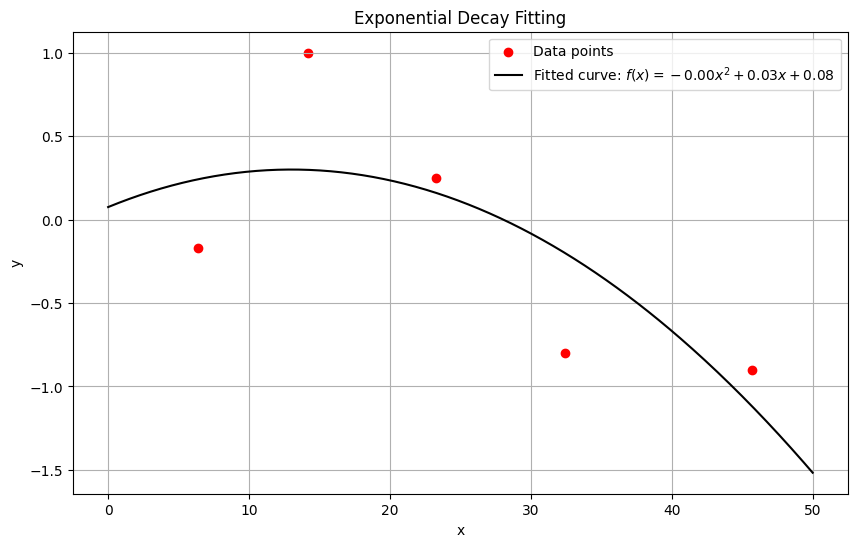

(-0.0013278910543705607, 0.03455791702900116, 0.07516002756790159)

In [247]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Data points
x_data = np.array([6.38, 14.2, 23.25, 32.45, 45.7])
y_data = np.array([-0.17, 1, 0.25, -0.8, -0.9])


# Define the exponential decay function
def exp_decay(x, a, b, c):
    return a * x**2 + b * x + c  # a * np.exp(-b * x)


# Perform the curve fitting
params, params_covariance = curve_fit(exp_decay, x_data, y_data, p0=[0.1, 1, 1])

# Extract the parameters
a, b, c = params

# Generate fitted data for plotting
x_fit = np.linspace(0, 50, 400)
y_fit = exp_decay(x_fit, a, b, c)

# Plot the data points and the fitted curve
plt.figure(figsize=(10, 6))
plt.scatter(x_data, y_data, color="red", label="Data points")
plt.plot(x_fit, y_fit, label=f"Fitted curve: $f(x) = {a:.2f}x^2 + {b:.2f}x + {c:.2f}$", color="black")
plt.title("Exponential Decay Fitting")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()

# Display the fitted parameters
a, b, c

In [256]:
def model_func(X, a1, a2, a3, b, c):
    r, color, rainrate = X
    return (
        # a[0] * np.exp(-a[1] * X[r]) * b * X[color] + c * X[rainrate] # [0.34, 0.077]
        (a1 * X[r] ** 2 + a2 * X[r] + a3) + (b * X[color]) + (c * X[rainrate])
    )  # a[0] + a[1] * X[r] + a[2] * X[r] ** 2 // [0.095, 0.031, -0.00124]


# plot_data = regression_data[(regression_data["color"] == "white")]
plot_data = regression_data.reset_index(names="timestamp")

fig = go.Figure()
fig.add_trace(
    go.Scatter(
        x=plot_data.index,
        y=plot_data["precipitation.intensity_hour_shifted"],
        mode="lines",
        name="Rainfall Rate",
    )
)
fig.add_trace(
    go.Scatter(
        x=plot_data.index,
        y=plot_data["intensity"],
        mode="markers",
        name="Target Intensity",
        text=plot_data["target"],
        marker=dict(size=5, color=plot_data["color"]),
    )
)
fig.add_trace(
    go.Scatter(
        x=plot_data.index,
        y=model_func(
            plot_data[["range", "reflectivity", "precipitation.intensity_hour_shifted"]],
            -0.0013278910543705607,
            0.03455791702900116,
            0.07516002756790159,
            2,
            -0.1,
        ),
        mode="lines",
        name="model",
    )
)
fig.update_layout(height=800, width=1600)

In [270]:
from scipy.optimize import curve_fit

# Sample data loading
model_data = regression_data.reset_index(names="timestamp").dropna()
# Handle missing values in intensity
# model_data["intensity"].interpolate(method="linear", inplace=True)

# Prepare the data for curve fitting
X_data = model_data[["range", "reflectivity", "precipitation.intensity_hour_shifted"]]
y_data = model_data["intensity"]

# Initial guess for the parameters
initial_guess = [
    -0.0013278910543705607,
    0.03455791702900116,
    0.07516002756790159,
    2,
    -0.1,
]

# Fit the model using curve_fit
params, covariance = curve_fit(model_func, X_data, y_data, p0=initial_guess)

# Extract the fitted parameters
a1, a2, a3, b, c = params

print(f"Fitted parameters:\na1 = {a1}\na1 = {a2}\na1 = {a3}\nb = {b}\nc = {c}")

# Predict the intensity using the fitted model
model_data["predicted_intensity"] = model_func(X_data, *params)

# Filter the data for a specific reflectivity and range
# reflectivity_value = 0.9  # Example: white
# range_value = 32.45  # Example: 14.20 m

# filtered_model_data = model_data[(model_data["reflectivity"] == reflectivity_value) & (model_data["range"] == range_value)]


fig = go.Figure()
fig.add_trace(
    go.Scatter(
        x=model_data.index,
        y=model_data["precipitation.intensity_hour_shifted"],
        mode="lines",
        name="Rainfall Rate",
    )
)
fig.add_trace(
    go.Scatter(
        x=model_data.index,
        y=model_data["intensity"],
        mode="markers",
        name="Target Intensity",
        text=model_data["target"],
        marker=dict(size=5, color=model_data["color"]),
    )
)
fig.add_trace(
    go.Scatter(
        x=model_data.index,
        y=model_data["predicted_intensity"],
        mode="lines",
        name="model",
    )
)
fig.update_layout(height=800, width=1600)

# Add linear and polynomial regression here

Fitted parameters:
a1 = -0.0011131313128554543
a1 = 0.03039332141423554
a1 = -0.6244542018270243
b = 1.5790179998427818
c = -0.10625349709753118


In [17]:
import statsmodels.api as sm

In [47]:
model_data = regression_data.loc[:, ["intensity", "precipitation.intensity_hour_shifted", "color", "range"]].copy()
color_mapping = {"white": 0.9, "grey": 0.45, "black": 0.06}
model_data["reflectivity"] = model_data["color"].map(color_mapping)
model_data["precipitation.intensity_hour_shifted"].fillna(0, inplace=True)
model_data.dropna(subset=["intensity"], inplace=True)
model_data

,intensity,precipitation.intensity_hour_shifted,color,range,reflectivity
2023-08-29 04:05:00,0.861677,-0.692673,white,6.38,0.9
2023-08-29 04:05:00,3.144381,-0.692673,white,14.20,0.9
2023-08-29 04:05:00,0.863485,-0.692673,white,23.25,0.9
2023-08-29 04:05:00,-0.262075,-0.692673,white,32.45,0.9
2023-08-29 04:05:00,-0.456434,-0.692673,white,45.70,0.9
...,...,...,...,...,...
2023-08-29 05:04:00,1.142331,0.000000,white,6.38,0.9
2023-08-29 05:04:00,4.423410,0.000000,white,14.20,0.9
2023-08-29 05:04:00,1.362804,0.000000,white,23.25,0.9
2023-08-29 05:04:00,-0.225640,0.000000,white,32.45,0.9


In [49]:
# Define the independent variables (R, D, Ref)
X = model_data.loc[:, ["precipitation.intensity_hour_shifted", "range", "reflectivity"]]

# Define the dependent variable (I)
y = model_data["intensity"]

# Fit the model
model = LinearRegression()
model.fit(X, y)

# Print the summary of the regression
# print(model.summary())

LinearRegression()

In [52]:
filtered_data = model_data.loc[(model_data["range"] == 14.20) & (model_data["color"] == "black")]

In [53]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Create subplots: one row, one column
fig = make_subplots(rows=1, cols=1)

# Add rain rate trace
fig.add_trace(
    go.Scatter(
        x=filtered_data.index,
        y=filtered_data["precipitation.intensity_hour_shifted"],
        mode="lines",
        name="Rain Rate (mm/h)",
        marker=dict(color="blue"),
    ),
    row=1,
    col=1,
)

# Add observed intensity trace
fig.add_trace(
    go.Scatter(
        x=filtered_data.index,
        y=filtered_data.intensity,
        mode="lines",
        name="Observed Intensity",
        marker=dict(color="green"),
    ),
    row=1,
    col=1,
)

# Add predicted intensity trace
fig.add_trace(
    go.Scatter(
        x=filtered_data.index,
        y=model.predict(filtered_data.loc[:, ["precipitation.intensity_hour_shifted", "range", "reflectivity"]]),
        mode="lines",
        name="Predicted Intensity",
        line=dict(color="red", dash="dash"),
    ),
    row=1,
    col=1,
)

# Update layout
fig.update_layout(
    title_text="Rain Rate, Observed Intensity, and Predicted Intensity",
    xaxis_title="Time",
    yaxis_title="Values",
    legend_title="Legend",
    template="plotly_white",
)

fig.show()

ValueError: Found array with 0 sample(s) (shape=(0, 3)) while a minimum of 1 is required by LinearRegression.

### Model Selection

In [172]:
X = df_relevant.precipitation.intensity_hour_shifted.values.reshape(-1, 1)
X[-1] = 0
y = subtarget_statistics["Target-03"]["white"].values

# Initialize and train the model
model = LinearRegression()
model.fit(X, y)

LinearRegression()

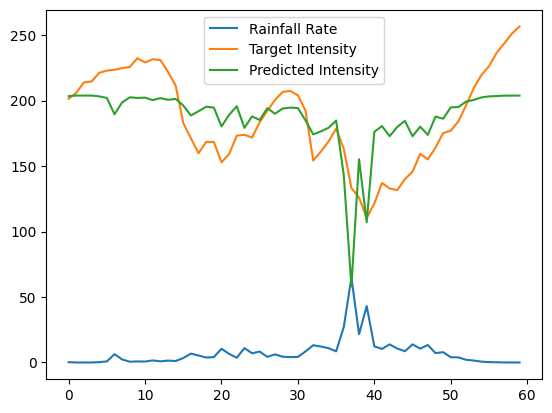

In [173]:
# Make predictions
plt.plot(X, label="Rainfall Rate")
plt.plot(y, label="Target Intensity")
plt.plot([model.predict([x]) for x in X], label="Predicted Intensity")
plt.legend()

RMSE: 18.765906477946825
R-squared: 0.7226173740456029


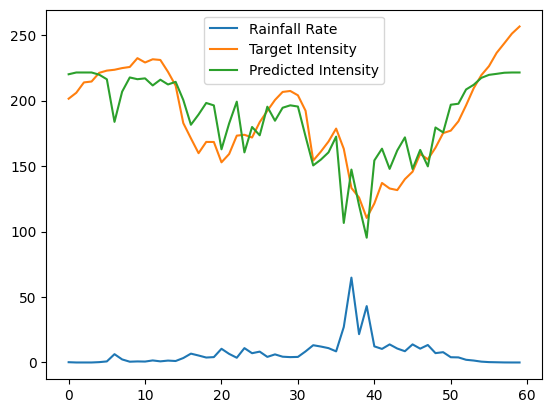

In [13]:
# Define the degree of the polynomial
degree = 2

# Create polynomial features
poly = PolynomialFeatures(degree)
X_poly = poly.fit_transform(X)


# Split data into training and testing sets
# X_train, X_test, y_train, y_test = train_test_split(X_poly, y, test_size=0.1, random_state=42)
X_train = X_test = X_poly
y_train = y_test = y

# Train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse}")
print(f"R-squared: {r2}")


# Make predictions
plt.plot(X, label="Rainfall Rate")
plt.plot(y, label="Target Intensity")
plt.plot(model.predict(X_train), label="Predicted Intensity")
plt.legend()

In [133]:
regression_data = []
for target, color in subtarget_statistics.columns:
    # if target == "Target-04" and color == "black":
    #     continue
    df = pd.DataFrame(
        {
            "rainfall_rate": df_relevant.precipitation.intensity_hour_shifted,
            "target_intensity": subtarget_statistics[target][color],
            "target": f"{target}_{color}",
            "distance": TARGET_DISTANCES[target],
        }
    )
    # Deal with nan in the last value for the rainfall rate
    df.loc[df.index[-1], "rainfall_rate"] = 0
    regression_data.append(df)

regression_data = pd.concat(regression_data)
regression_data = regression_data.dropna()

In [134]:
# Feature Engineering
# regression_data['rainfall_rate_squared'] = df['rainfall_rate']**2
# df['range_squared'] = df['range']**2
# df['interaction'] = df['rainfall_rate'] * df['range']

# Define features and target
X = regression_data[
    ["rainfall_rate", "distance"]  ###### reflectiviy!!!!!
]  # , 'range', 'reflectivity', 'rainfall_rate_squared', 'range_squared', 'interaction']]
y = regression_data["target_intensity"]

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

# List of models to evaluate
models = [
    ("Linear Regression", LinearRegression()),
    ("Polynomial Regression (Degree 3)", make_pipeline(PolynomialFeatures(degree=2), LinearRegression())),
    ("Random Forest Regression", RandomForestRegressor(n_estimators=100, random_state=42)),
    ("Gradient Boosting Regression", GradientBoostingRegressor(n_estimators=100, random_state=42)),
    ("Support Vector Regression", make_pipeline(StandardScaler(), SVR(kernel="rbf"))),
]

# Loop over models and evaluate
results = []
for name, model in models:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    results.append((name, rmse, r2))

    print(f"{name} - RMSE: {rmse}, R-squared: {r2}")

    # Plot the results
    fig = go.Figure()
    fig.add_trace(
        go.Scatter(
            x=np.arange(len(regression_data)), y=regression_data["rainfall_rate"], mode="lines", name="Rainfall Rate"
        )
    )
    fig.add_trace(
        go.Scatter(
            x=np.arange(len(regression_data)),
            y=y,
            mode="lines",
            name="Target Intensity",
            text=regression_data["target"],
        )
    )
    fig.add_trace(
        go.Scatter(x=np.arange(len(regression_data)), y=model.predict(X), mode="lines", name="Predicted Intensity")
    )
    fig.update_layout(title=name)
    fig.show()


# Summarize results
for name, rmse, r2 in results:
    print(f"{name} - RMSE: {rmse:.4f}, R-squared: {r2:.4f}")

Linear Regression - RMSE: 87.89964770971316, R-squared: 0.1375004617163852


Polynomial Regression (Degree 3) - RMSE: 87.06647598483629, R-squared: 0.15377366672153514


Random Forest Regression - RMSE: 122.66621350047214, R-squared: -0.6797108262183846


Gradient Boosting Regression - RMSE: 95.43906398435564, R-squared: -0.016803295235153337


Support Vector Regression - RMSE: 82.58838359338077, R-squared: 0.23858305993905804


Linear Regression - RMSE: 87.8996, R-squared: 0.1375
Polynomial Regression (Degree 3) - RMSE: 87.0665, R-squared: 0.1538
Random Forest Regression - RMSE: 122.6662, R-squared: -0.6797
Gradient Boosting Regression - RMSE: 95.4391, R-squared: -0.0168
Support Vector Regression - RMSE: 82.5884, R-squared: 0.2386
